In [302]:
# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import pandas as pd
import os

# To plot pretty figures
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "diabetes_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [303]:
train_df = pd.read_csv('Diabetes-train.csv')
train_df.head()

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,343,1,0.0,68,35,No,32.0,0.389,22,No
1,496,6,166.0,74,No,No,26.6,0.304,66,No
2,1429,10,162.0,84,No,No,27.7,0.182,54,No
3,1722,0,84.0,82,31,125,38.2,0.233,23,No
4,1614,12,140.0,82,43,325,39.2,0.528,58,Yes


In [304]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        800 non-null    int64  
 1   Pregnancies               800 non-null    int64  
 2   Glucose                   799 non-null    float64
 3   BloodPressure             800 non-null    object 
 4   SkinThickness             799 non-null    object 
 5   Insulin                   800 non-null    object 
 6   BMI                       800 non-null    float64
 7   DiabetesPedigreeFunction  800 non-null    float64
 8   Age                       800 non-null    int64  
 9   Outcome                   800 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 62.6+ KB


In [305]:
train_df = train_df.dropna()
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 798 entries, 0 to 799
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        798 non-null    int64  
 1   Pregnancies               798 non-null    int64  
 2   Glucose                   798 non-null    float64
 3   BloodPressure             798 non-null    object 
 4   SkinThickness             798 non-null    object 
 5   Insulin                   798 non-null    object 
 6   BMI                       798 non-null    float64
 7   DiabetesPedigreeFunction  798 non-null    float64
 8   Age                       798 non-null    int64  
 9   Outcome                   798 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 68.6+ KB


In [306]:
train_df['Outcome'].value_counts()

Outcome
No     530
Yes    268
Name: count, dtype: int64

In [307]:
train_df[['BloodPressure', 'SkinThickness', 'Insulin']] = train_df[['BloodPressure', 'SkinThickness', 'Insulin']].replace('No', 0)
train_df['BloodPressure'] = train_df['BloodPressure'].replace("Don't Know", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("1No", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("2No", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("3No", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("4No", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("5No", 0)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("4.2cm", 4.2)
train_df['SkinThickness'] = train_df['SkinThickness'].replace("3.5cm", 3.5)
train_df['Insulin'] = train_df['Insulin'].replace("22No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("5No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("14No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("12No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("24No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("16No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("51No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("18No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("1NoNo", 0)
train_df['Insulin'] = train_df['Insulin'].replace("1No5", 0)
train_df['Insulin'] = train_df['Insulin'].replace("4No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("1No6", 0)
train_df['Insulin'] = train_df['Insulin'].replace("17No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("13No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("9No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("2No4", 0)
train_df['Insulin'] = train_df['Insulin'].replace("21No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("11No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("48No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("1No8", 0)
train_df['Insulin'] = train_df['Insulin'].replace("3No4", 0)
train_df['Insulin'] = train_df['Insulin'].replace("2NoNo", 0)
train_df['Insulin'] = train_df['Insulin'].replace("19No", 0)
train_df['Insulin'] = train_df['Insulin'].replace("15No", 0)
train_df[['BloodPressure', 'SkinThickness', 'Insulin']] = train_df[['BloodPressure', 'SkinThickness', 'Insulin']].astype('float')

In [308]:
train_df = train_df.drop('ID', axis=1)
train_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,0.0,68.0,35.0,0.0,32.0,0.389,22,No
1,6,166.0,74.0,0.0,0.0,26.6,0.304,66,No
2,10,162.0,84.0,0.0,0.0,27.7,0.182,54,No
3,0,84.0,82.0,31.0,125.0,38.2,0.233,23,No
4,12,140.0,82.0,43.0,325.0,39.2,0.528,58,Yes


In [309]:
train_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000
mean,3.694236,120.917293,69.854637,18.158772,63.817043,32.272807,0.467989,33.047619
std,3.252524,32.110196,19.100708,16.119596,100.789090,7.287515,0.309133,11.605832
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.084000,21.000000
25%,1.000000,98.000000,64.000000,0.000000,0.000000,27.700000,0.241000,24.000000
50%,3.000000,117.000000,72.000000,19.000000,0.000000,32.300000,0.381500,29.000000
75%,6.000000,140.000000,80.000000,32.000000,103.750000,36.500000,0.619000,40.000000
max,17.000000,199.000000,122.000000,99.000000,545.000000,59.400000,2.420000,72.000000


In [310]:
condition = train_df['BMI']==0
train_df[condition]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
29,0,118.0,64.0,23.0,89.0,0.0,1.731,21,No
174,5,136.0,82.0,0.0,0.0,0.0,0.640,69,No
385,0,102.0,75.0,23.0,0.0,0.0,0.572,21,No
409,0,94.0,0.0,0.0,0.0,0.0,0.256,25,No
426,0,102.0,75.0,23.0,0.0,0.0,0.572,21,No
570,6,114.0,0.0,0.0,0.0,0.0,0.189,26,No
627,6,114.0,0.0,0.0,0.0,0.0,0.189,26,No


In [311]:
train_df = train_df.loc[~(train_df['BMI'] == 0)]
train_df.shape

(791, 9)

In [312]:
condition = train_df['BloodPressure']==0
train_df[condition]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
32,8,120.0,0.0,0.0,0.0,30.0,0.183,38,Yes
141,4,90.0,0.0,0.0,0.0,28.0,0.610,31,No
154,3,116.0,0.0,0.0,0.0,23.5,0.187,23,No
160,0,141.0,0.0,0.0,0.0,42.4,0.205,29,Yes
178,0,99.0,0.0,0.0,0.0,25.0,0.253,22,No
199,0,167.0,0.0,0.0,0.0,32.3,0.839,30,Yes
242,2,99.0,0.0,0.0,0.0,22.2,0.108,23,No
246,2,146.0,0.0,0.0,0.0,27.5,0.240,28,Yes
264,4,90.0,0.0,0.0,0.0,28.0,0.610,31,No
279,13,129.0,0.0,0.0,0.0,39.9,0.569,44,Yes


In [313]:
train_df = train_df.loc[~(train_df['BloodPressure'] == 0)]
train_df.shape

(761, 9)

In [314]:
train_df = train_df.replace(to_replace=["No"], value="0")
train_df = train_df.replace(to_replace=["Yes"], value="1")
train_df['Outcome'] = train_df['Outcome'].astype(int)
train_df.head() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,0.0,68.0,35.0,0.0,32.0,0.389,22,0
1,6,166.0,74.0,0.0,0.0,26.6,0.304,66,0
2,10,162.0,84.0,0.0,0.0,27.7,0.182,54,0
3,0,84.0,82.0,31.0,125.0,38.2,0.233,23,0
4,12,140.0,82.0,43.0,325.0,39.2,0.528,58,1


Saving figure attribute_histogram_plots


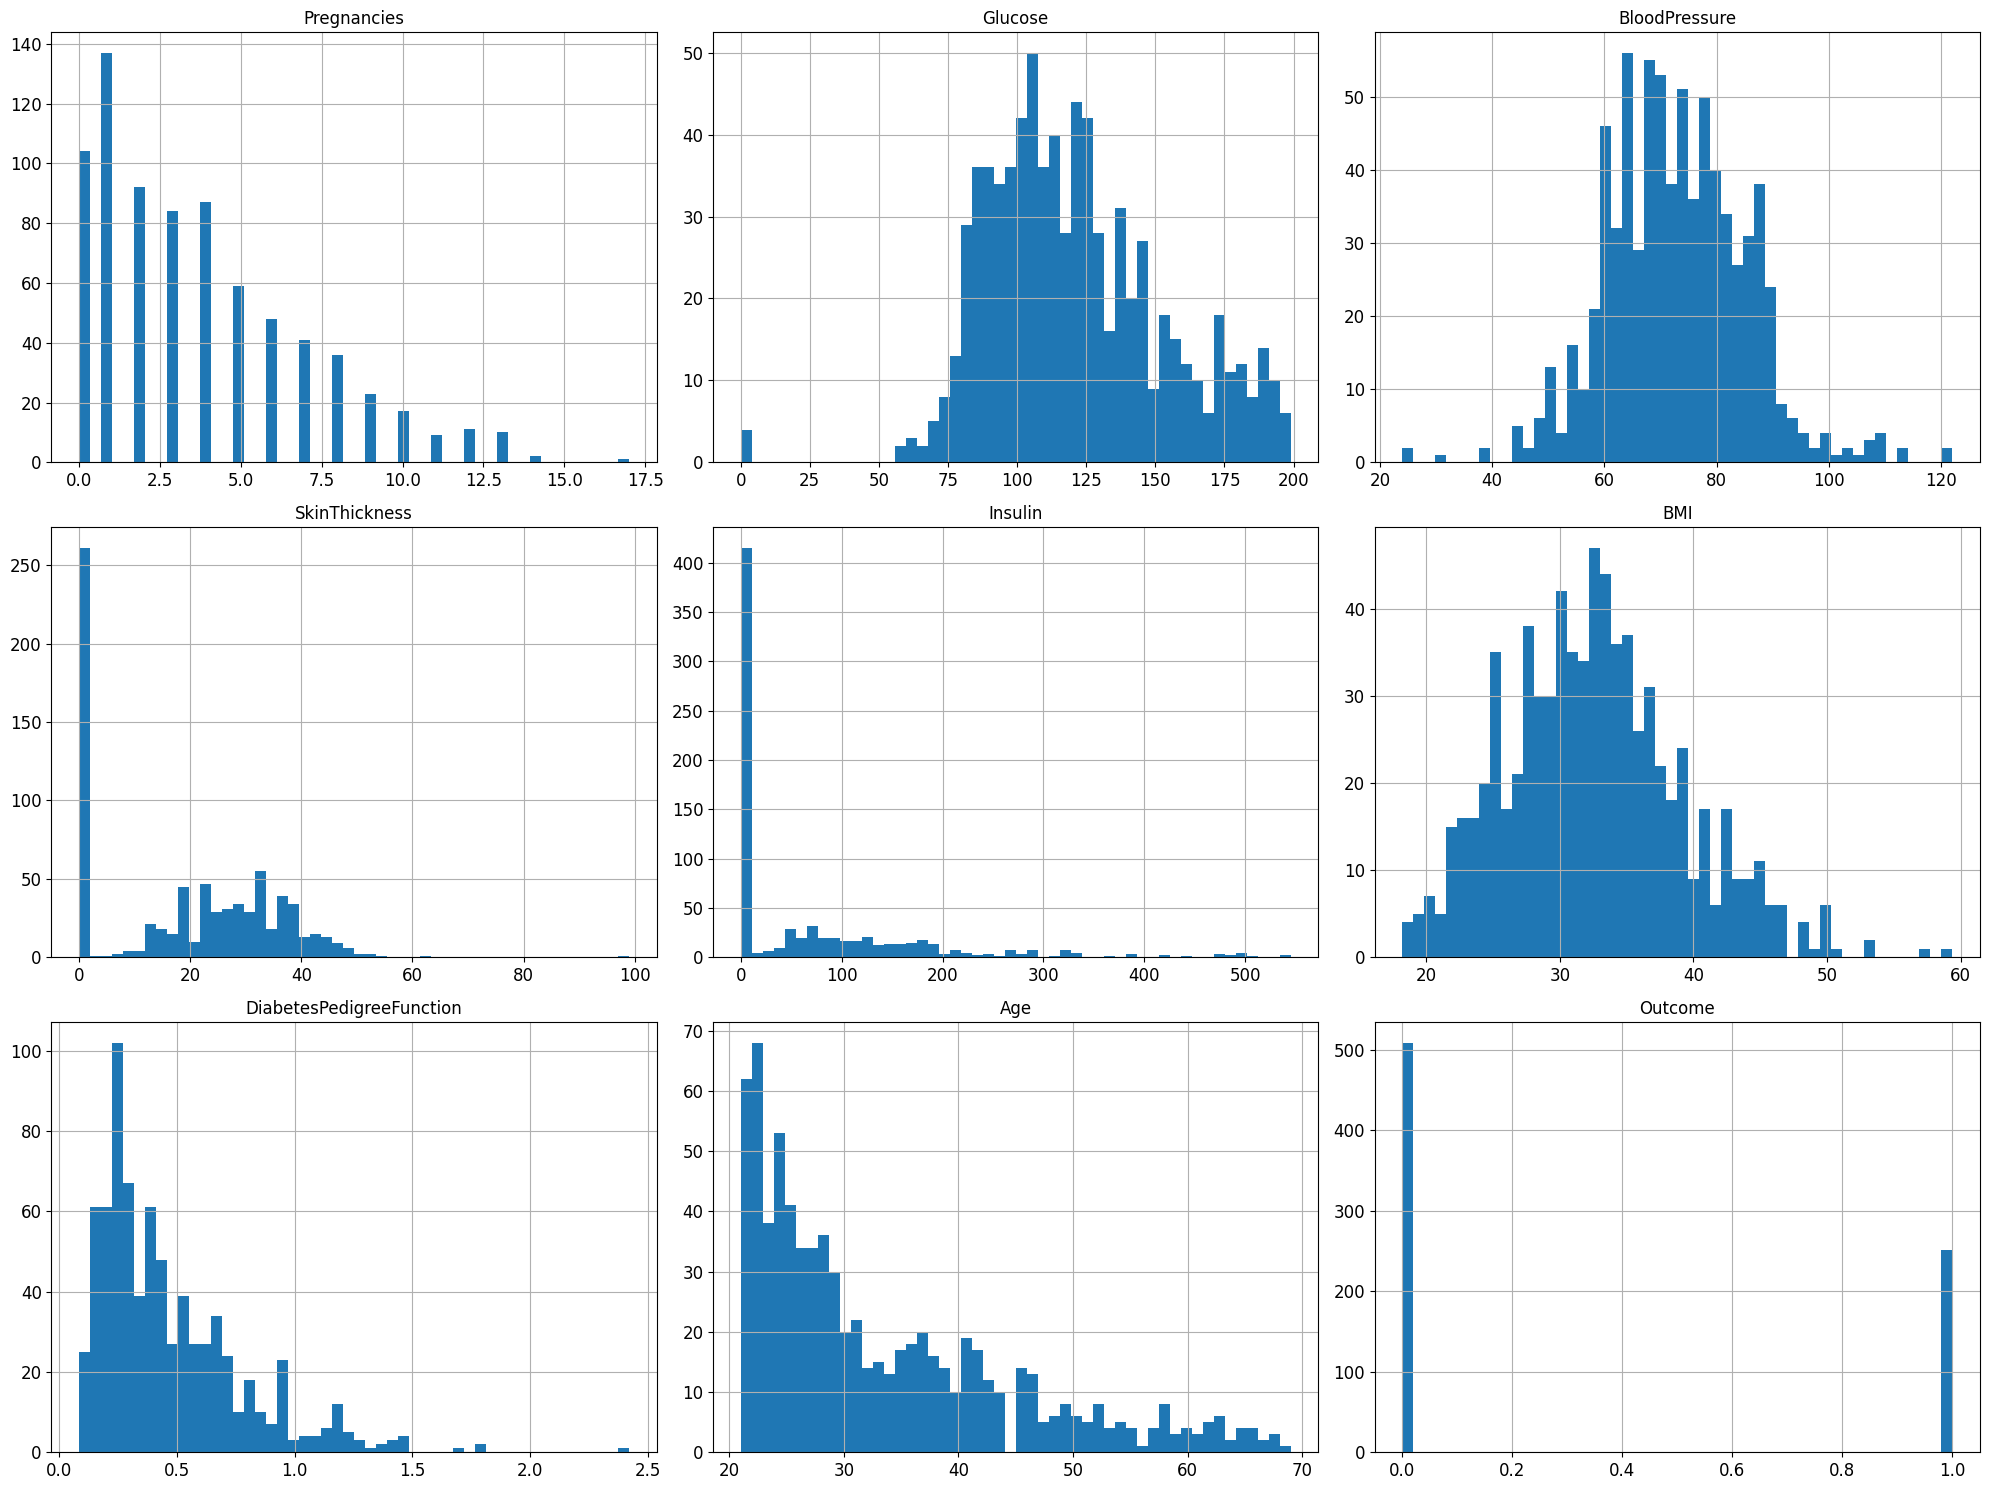

In [315]:
train_df.hist(bins=50, figsize=(20,15))
save_fig("attribute_histogram_plots")
plt.show()

Saving figure attribute_histogram_plots(Outcome)


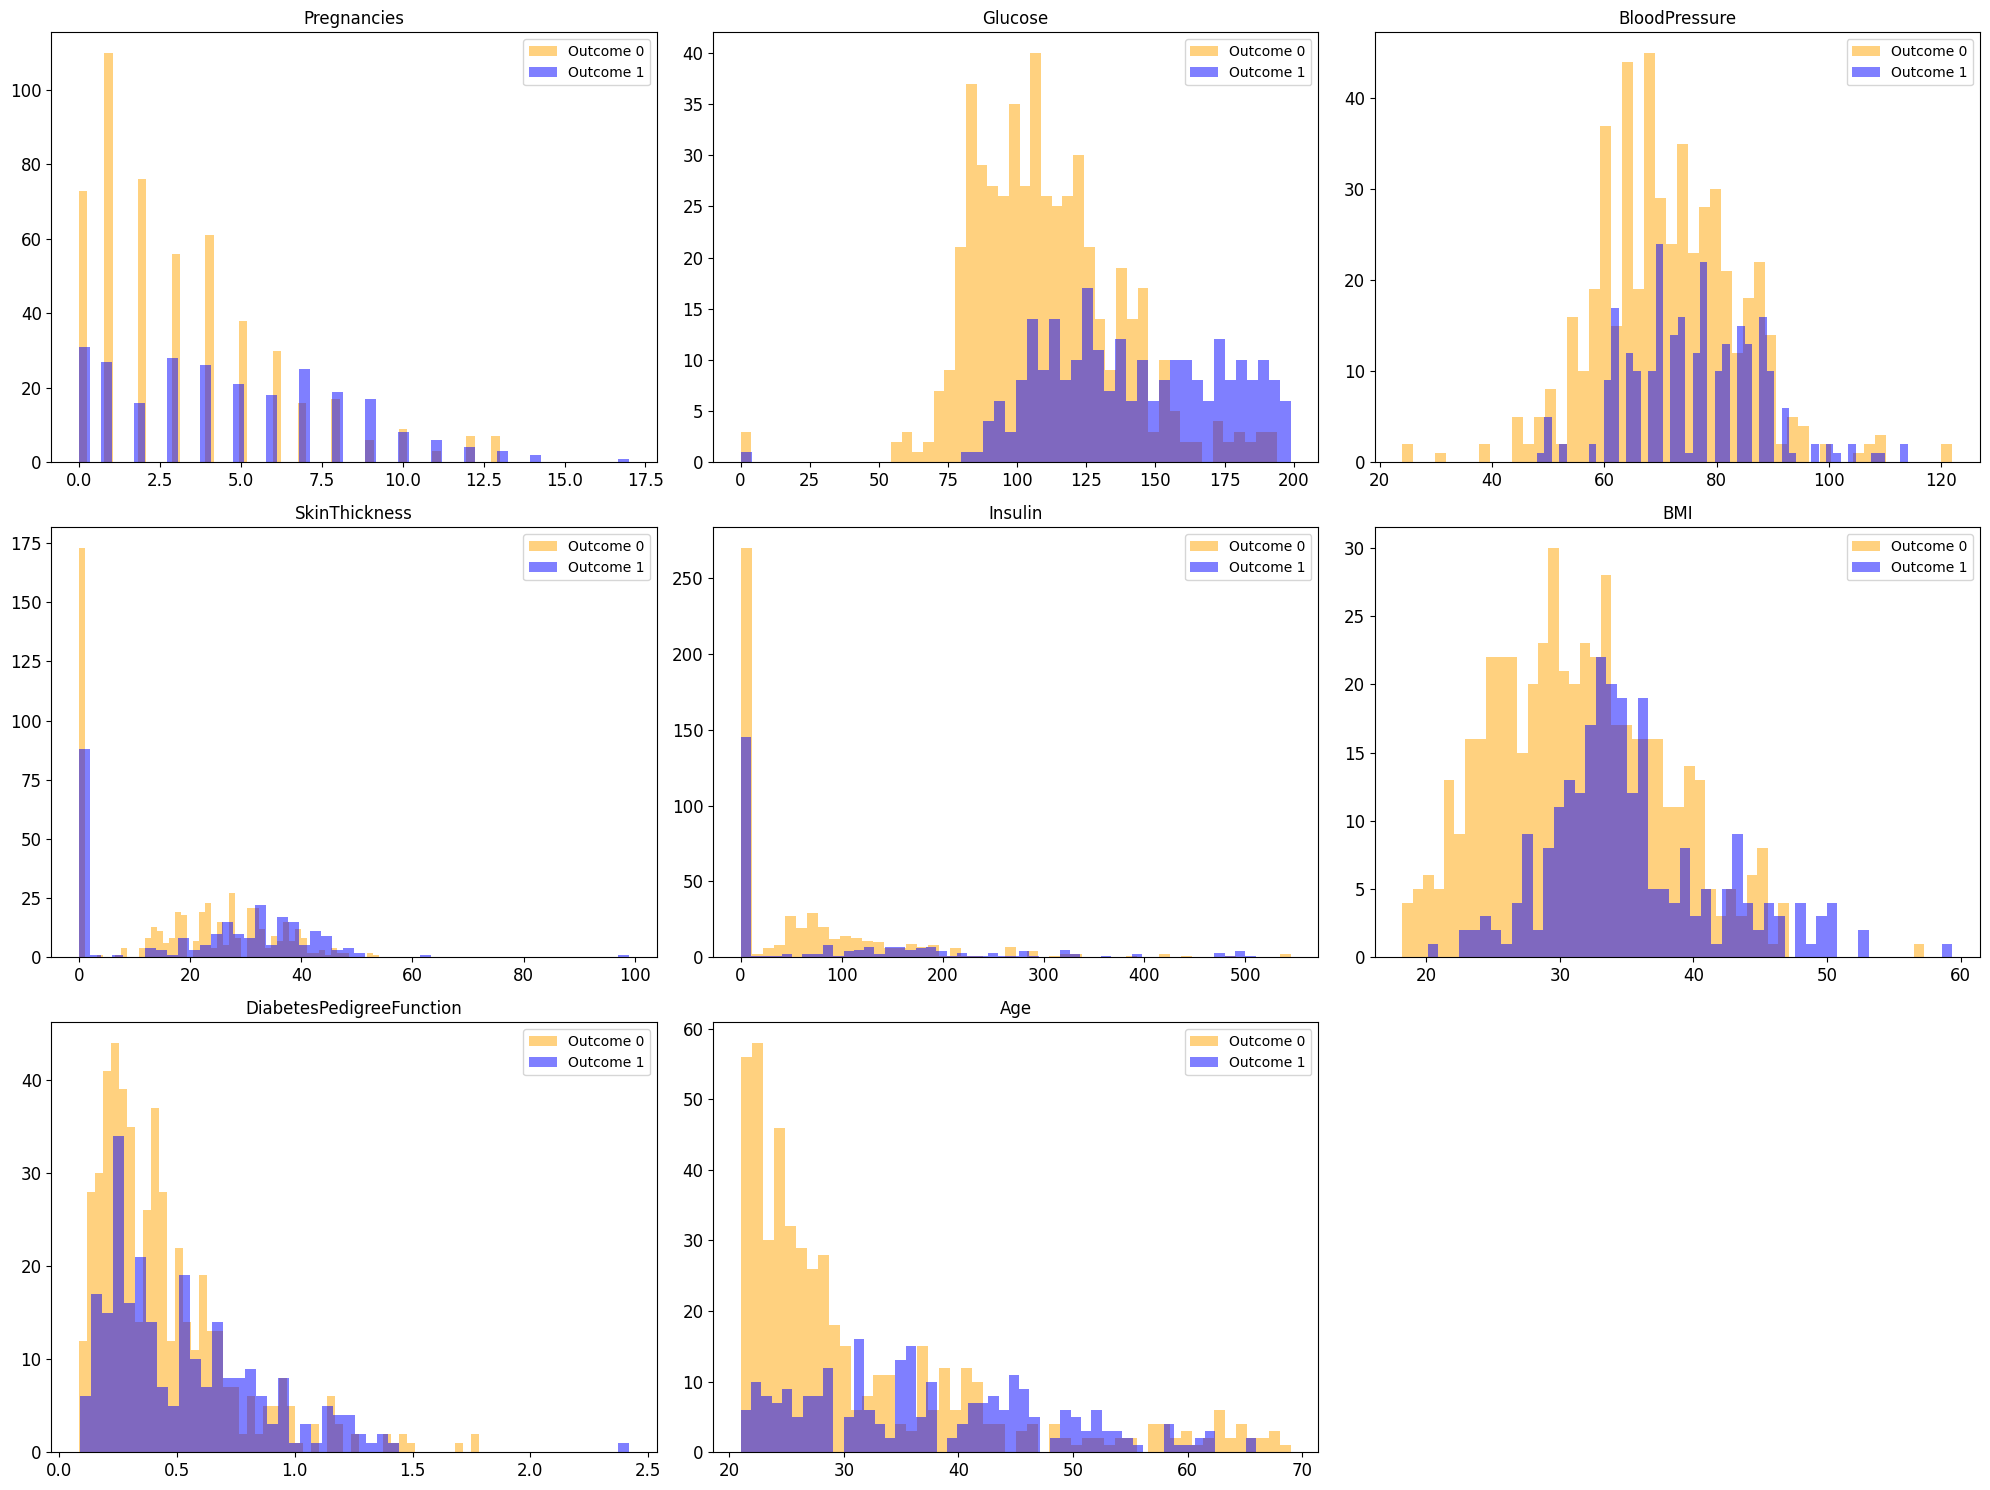

In [316]:
fig, axes = plt.subplots(3, 3,figsize=(20, 15))
features = train_df.columns[:-1]

for i, feature in enumerate(features):
    row = i//3
    col = i%3
    for outcome in [0, 1]:
        subset = train_df[train_df['Outcome'] == outcome][feature]
        axes[row, col].hist(subset, bins=50, alpha=0.5, label=f'Outcome {outcome}',
                            color=['orange', 'blue'][outcome])
        axes[row, col].set_title(feature)
        axes[row, col].legend()
axes[2, 2].axis('off')        
save_fig("attribute_histogram_plots(Outcome)")
plt.show()


相關性矩陣


In [317]:
corr_matrix = train_df.corr()
corr_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.155430,0.188124,-0.101273,-0.064781,0.045974,-0.035628,0.553513,0.232565
Glucose,0.155430,1.000000,0.267935,0.103679,0.277479,0.206767,0.120181,0.300249,0.466631
BloodPressure,0.188124,0.267935,1.000000,0.049828,-0.075138,0.313622,-0.016222,0.351342,0.171516
SkinThickness,-0.101273,0.103679,0.049828,1.000000,0.313631,0.327529,0.133302,-0.100563,0.105080
Insulin,-0.064781,0.277479,-0.075138,0.313631,1.000000,0.097257,0.169605,-0.055457,0.124923
BMI,0.045974,0.206767,0.313622,0.327529,0.097257,1.000000,0.161960,0.064597,0.278219
DiabetesPedigreeFunction,-0.035628,0.120181,-0.016222,0.133302,0.169605,0.161960,1.000000,0.042603,0.144899
Age,0.553513,0.300249,0.351342,-0.100563,-0.055457,0.064597,0.042603,1.000000,0.251345
Outcome,0.232565,0.466631,0.171516,0.105080,0.124923,0.278219,0.144899,0.251345,1.000000


Saving figure corr_matrix_plots


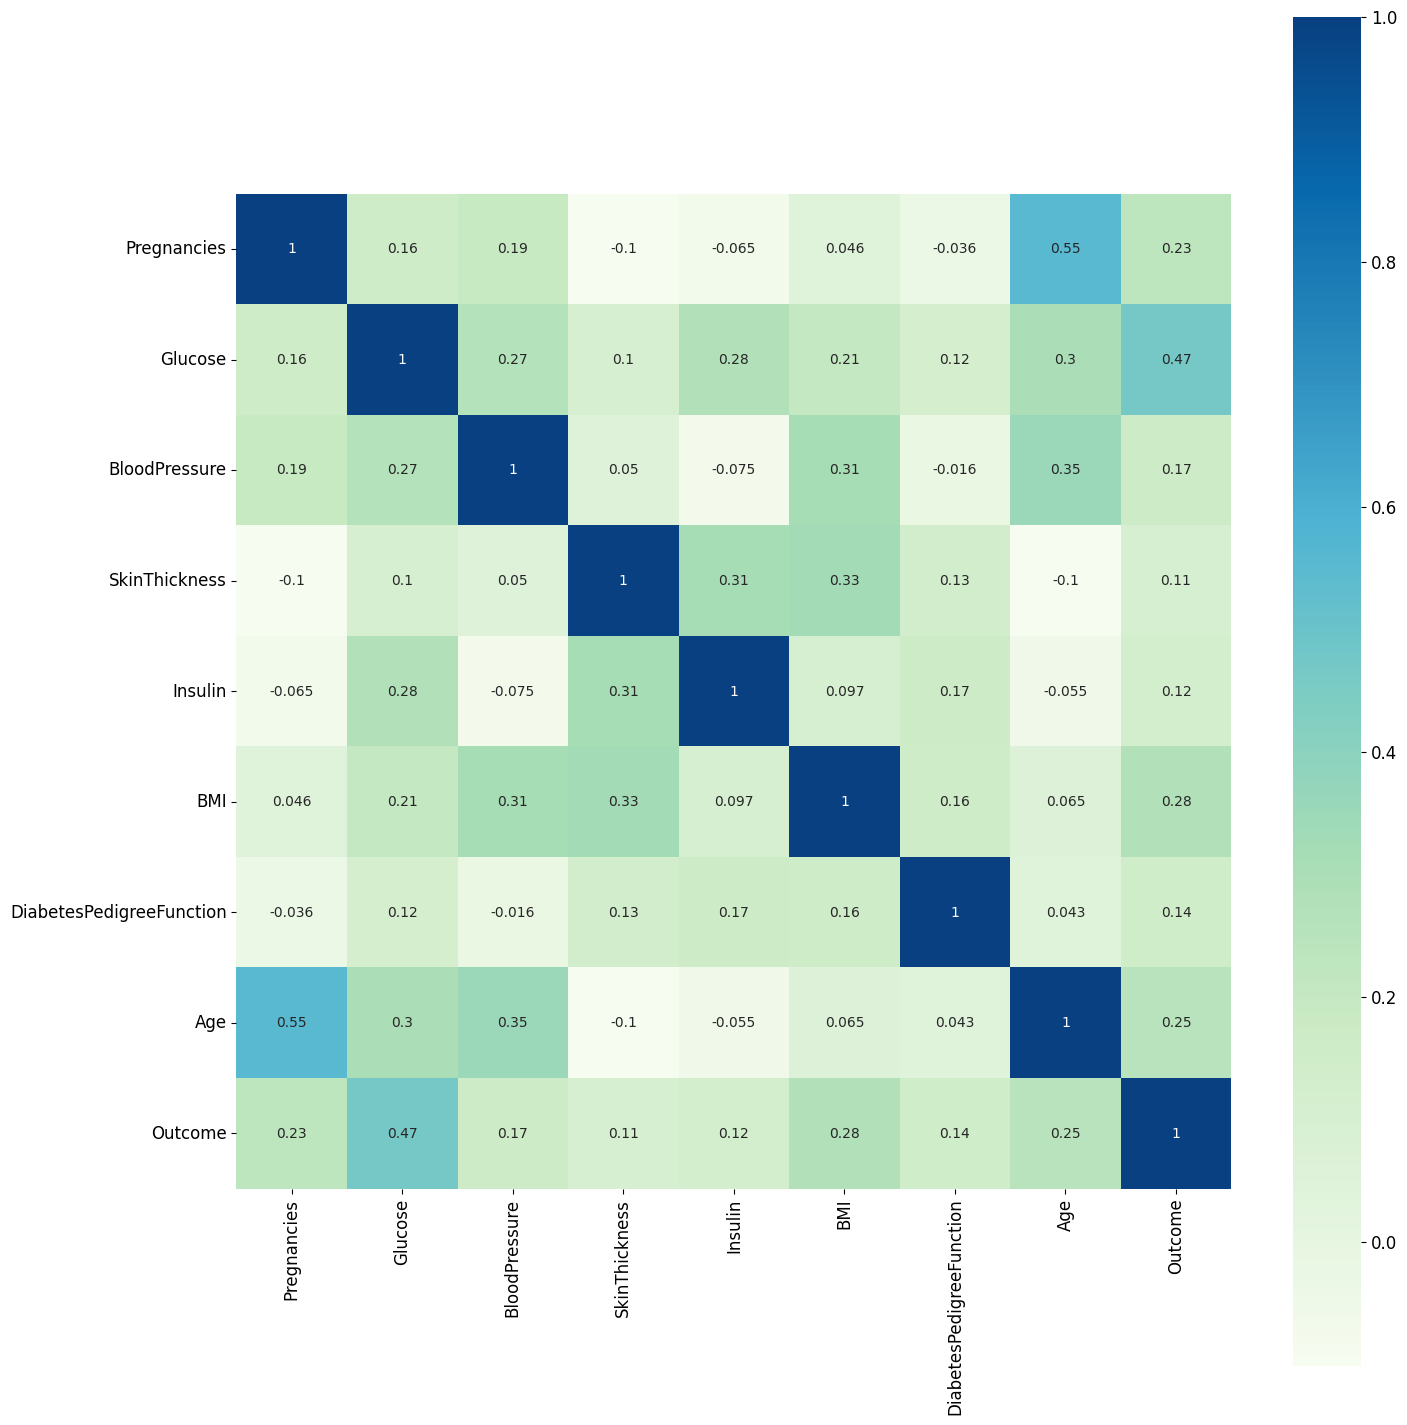

In [318]:
import seaborn as sns
plt.figure(figsize=(15,15))
ax = sns.heatmap(corr_matrix, square=True, annot=True, cmap='GnBu')
save_fig("corr_matrix_plots")
plt.show()

Data Preprocessing

In [319]:
"""發現SkinThickness和Insulin欄位有很多為0可能為缺失值，使用KNNImputer進行填補"""


X = train_df.drop('Outcome', axis=1)
y = train_df['Outcome']

#0替換為NaN
X[['SkinThickness', 'Insulin']] = (X[['SkinThickness', 'Insulin']].replace(0, np.nan))

#資料分割
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

cols = train_X.columns

train_index = train_X.index
test_index = test_X.index

# StandardScaler
scaler = StandardScaler()

train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

# KNN Imputer
imputer = KNNImputer(n_neighbors=5)

train_X_imputed = imputer.fit_transform(train_X_scaled)
test_X_imputed = imputer.transform(test_X_scaled)

train_X_imputed = pd.DataFrame(train_X_imputed, columns = cols, index = train_index)
test_X_imputed = pd.DataFrame(test_X_imputed, columns = cols, index = test_index)
train_X_imputed.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
382,0.987312,1.210574,0.994091,0.464936,0.464564,-0.350553,-0.998086,1.177632
280,0.371634,-1.474773,-1.006748,-0.409366,-0.889287,-0.890747,-0.671385,-0.541869
93,0.987312,1.149544,-0.545016,0.074291,2.012389,-0.350553,-0.306621,0.231906
391,0.371634,0.447692,0.840180,1.134615,-0.531031,0.339694,-0.614292,0.145931
607,1.602990,1.515727,2.841019,-0.446570,-0.097561,1.900254,0.765466,1.779457


Select and Train a Model

In [320]:
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [321]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    'SVM': SVC(),
    'Perceptron': Perceptron(random_state=42),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=3000,
        random_state=42
    )
}

In [322]:
results = {}

for name, model in models.items():

    # 訓練模型
    model.fit(train_X_imputed, train_y)

    # 預測
    pred = model.predict(test_X_imputed)

    # 將預測結果轉成 0 / 1
    pred = threshold_predictions(pred)

    # MSE
    mse = mean_squared_error(test_y, pred)

    # MAE
    mae = mean_absolute_error(test_y, pred)

    # Accuracy
    accuracy = accuracy_score(test_y, pred)

    # 儲存結果
    results[name] = {
        'MSE': mse,
        'MAE': mae,
        'Accuracy': accuracy
    }

results_df = pd.DataFrame(results).T

results_df

,MSE,MAE,Accuracy
Logistic Regression,0.209150,0.209150,0.790850
Decision Tree,0.169935,0.169935,0.830065
Random Forest,0.111111,0.111111,0.888889
SVM,0.202614,0.202614,0.797386
Perceptron,0.339869,0.339869,0.660131
MLP,0.196078,0.196078,0.803922


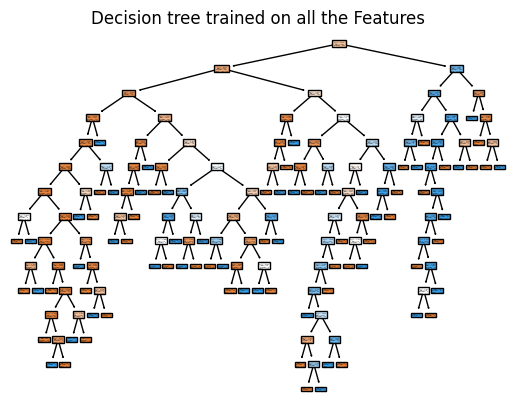

In [323]:
from sklearn import tree
from sklearn.tree import plot_tree #圖
dt = DecisionTreeClassifier(random_state=42)
dt = dt.fit(train_X_imputed, train_y)
plt.figure()
tree.plot_tree(dt, filled=True) #filled=True套色
plt.title("Decision tree trained on all the Features")
plt.show()

Model Tuning and Analyzing the Best Models

In [324]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [327]:
#CV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Decision Tree

dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer()),
    ('model', DecisionTreeClassifier(
        random_state=42
    ))
])

dt_params = {
    'imputer__n_neighbors': [3, 5, 7],
    'model__criterion': ['gini', 'entropy', 'log_loss'], # 樹分割的criterion有:“gini”, “entropy”, “log_loss”
    'model__max_depth': [3, 5, 8, None], #決策樹的深度
    'model__min_samples_split': [2, 5, 10], #內部節點至少需要多少資料數目，才去進行劃分
    'model__min_samples_leaf': [1, 2, 4], #每個最末節點(葉子)至少要有多少資料數目(samples)。
    'model__max_features': [3, 5, 8],  #最多使用多少變數去建立樹。
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

dt_grid.fit(train_X, train_y) # 跑沒預處理過的資料，因為pipeline裡面有scaler和imputer，所以不用先做預處理

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('imputer', KNNImputer()),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'imputer__n_neighbors': [3, 5, 7],
                         'model__criterion': ['gini', 'entropy', 'log_loss'],
                         'model__max_depth': [3, 5, 8, None],
                         'model__max_features': [3, 5, 8],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='roc_auc')

In [328]:
# Random Forest

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer()),
    ('model', RandomForestClassifier(
        random_state=42
    ))
])

rf_params = {
    'imputer__n_neighbors': [3, 5, 7],
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(train_X, train_y) # 跑沒預處理過的資料，因為pipeline裡面有scaler和imputer，所以不用先做預處理

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('imputer', KNNImputer()),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'imputer__n_neighbors': [3, 5, 7],
                         'model__max_depth': [None, 5, 10, 15],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200]},
             scoring='roc_auc')

In [330]:
# MLP

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer()),
    ('model', MLPClassifier(
        max_iter=3000,
        random_state=42
    ))
])

mlp_params = {
    'imputer__n_neighbors': [3, 5, 7],

    'model__hidden_layer_sizes': [
        (50,),
        (100,),
        (50, 50),
        (100, 50)
    ],

    'model__activation': ['relu', 'tanh'],

    'model__alpha': [0.0001, 0.001, 0.01],

    'model__learning_rate_init': [0.001, 0.01]
}

mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

mlp_grid.fit(train_X, train_y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('imputer', KNNImputer()),
                                       ('model',
                                        MLPClassifier(max_iter=3000,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'imputer__n_neighbors': [3, 5, 7],
                         'model__activation': ['relu', 'tanh'],
                         'model__alpha': [0.0001, 0.001, 0.01],
                         'model__hidden_layer_sizes': [(50,), (100,), (50, 50),
                                                       (100, 50)],
                         'model__learning_rate_init': [0.001, 0.01]},
             scoring='roc_auc')

In [331]:
print("===== Decision Tree =====")
print("Best parameters:")
print(dt_grid.best_params_)
print("Best CV ROC-AUC:")
print(dt_grid.best_score_)


print("\n===== Random Forest =====")
print("Best parameters:")
print(rf_grid.best_params_)
print("Best CV ROC-AUC:")
print(rf_grid.best_score_)


print("\n===== MLP =====")
print("Best parameters:")
print(mlp_grid.best_params_)
print("Best CV ROC-AUC:")
print(mlp_grid.best_score_)

===== Decision Tree =====
Best parameters:
{'imputer__n_neighbors': 3, 'model__criterion': 'gini', 'model__max_depth': None, 'model__max_features': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Best CV ROC-AUC:
0.848921258657031

===== Random Forest =====
Best parameters:
{'imputer__n_neighbors': 5, 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV ROC-AUC:
0.9291994128274617

===== MLP =====
Best parameters:
{'imputer__n_neighbors': 7, 'model__activation': 'tanh', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (100, 50), 'model__learning_rate_init': 0.01}
Best CV ROC-AUC:
0.8937707015959049


Final model

In [ ]:
best_model = best_grid.best_estimator_
# 預測
test_pred = best_model.predict(test_X)

# 將預測結果轉成 0 / 1
test_pred = threshold_predictions(test_pred)

test_prob = best_model.predict_proba(test_X)[:, 1]

test_accuracy = accuracy_score(test_y, test_pred)

test_precision = precision_score(test_y, test_pred)

test_recall = recall_score(test_y, test_pred)

test_f1 = f1_score(test_y, test_pred)

test_roc_auc = roc_auc_score(test_y, test_prob)



In [349]:
results = {
    'model': best_model_name,
    'cv_roc_auc': best_grid.best_score_,
    'test_accuracy': test_accuracy,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_f1': test_f1,
    'test_roc_auc': test_roc_auc
}

results_df = pd.DataFrame([results])

results_df.to_csv('model_results.csv',index=False)

results_df


,model,cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Random Forest,0.929199,0.888889,0.860465,0.770833,0.813187,0.939683


混淆矩陣：
 [[99  6]
 [11 37]]
Saving figure confusion_matrix


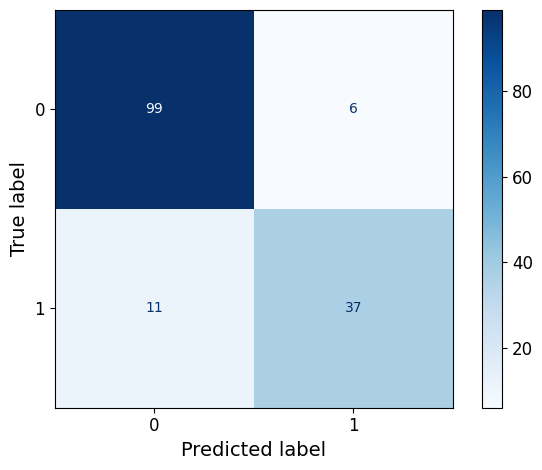

In [359]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# 計算混淆矩陣
cm = confusion_matrix(test_y, test_pred)
print("混淆矩陣：\n", cm)

# 繪製混淆矩陣圖形
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
save_fig("confusion_matrix")
plt.show()

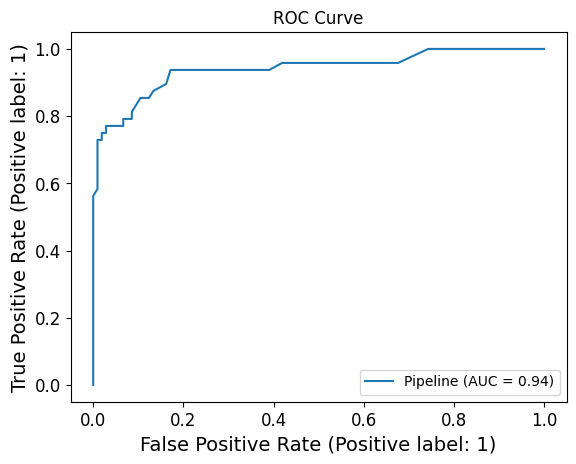

In [350]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    test_X,
    test_y
)

plt.title('ROC Curve')
plt.show()

In [ ]:
# 儲存最佳模型
import joblib

joblib.dump(
    best_model,
    'best_model.joblib'
)

['best_model.joblib']

Feature Importance

                    Feature  Importance
1                   Glucose    0.219860
4                   Insulin    0.159698
7                       Age    0.139198
5                       BMI    0.128056
6  DiabetesPedigreeFunction    0.116120
3             SkinThickness    0.099485
2             BloodPressure    0.074486
0               Pregnancies    0.063098
Saving figure Feature_Importance(Random Forest)


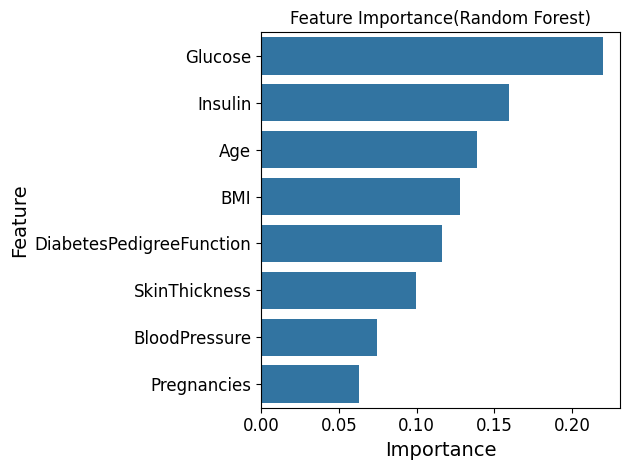

In [358]:
rf_model = best_model.named_steps['model']

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({'Feature': train_X.columns, 'Importance': importance})
feature_importance = feature_importance.sort_values('Importance',ascending=False)

print(feature_importance)

sns.barplot(x=feature_importance['Importance'], y=feature_importance['Feature'])
plt.title("Feature Importance(Random Forest)")
save_fig("Feature_Importance(Random Forest)")
plt.show()